# Customer Churn Prediction
## Deliverable P2: Modeling & Evaluation

**Dataset:** Telco Customer Churn (Kaggle)  
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

The goal here is to build a production-ready classification pipeline, evaluate model performance with the right metrics for an imbalanced target, and extract actionable business insights.


## 1. Environment Setup & Data Reconstruction

### 1.1 Import Libraries

All modeling libraries on top of the P1 stack.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Model selection & evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, recall_score, precision_score, average_precision_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Class imbalance
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titleweight'] = 'bold'


### 1.2 Reconstruct Dataset from P1

We re-run the full P1 pipeline in a single block so this notebook is self-contained and reproducible. No assumptions about a pre-loaded `df` in memory.


In [2]:
# ── Load ──────────────────────────────────────────────────────────────────
# Option 1: local CSV
# df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Option 2: Kaggle Hub (recommended for reproducibility)
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "blastchar/telco-customer-churn",
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

# ── P1 Wrangling ──────────────────────────────────────────────────────────
df = df.drop(columns=['customerID'])

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['SeniorCitizen'] = np.where(df['SeniorCitizen'] == 1, 'Yes', 'No')
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

df.columns = df.columns.str.lower().str.replace(' ', '_')
df.rename(columns={
    'tenure'         : 'months_as_customer',
    'monthlycharges' : 'monthly_charges',
    'totalcharges'   : 'total_charges',
}, inplace=True)

# ── P1 Feature Engineering ────────────────────────────────────────────────
df['tenure_segment'] = pd.cut(df['months_as_customer'],
                               bins=[0, 12, 36, 72],
                               labels=['New', 'Mid', 'Loyal'],
                               include_lowest=True)

services = ['onlinesecurity', 'onlinebackup', 'deviceprotection',
            'techsupport', 'streamingtv', 'streamingmovies']
df['total_services'] = (df[services] == 'Yes').sum(axis=1)

df['avg_monthly_charges'] = (
    df['total_charges'] / df['months_as_customer'].replace(0, 1)
).round(2)

print(f"Dataset reconstructed: {df.shape}")
print(f"Churn rate: {df['churn'].mean():.3f}")


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset reconstructed: (7043, 23)
Churn rate: 0.265


## 2. Preprocessing Pipeline

### 2.1 Feature Selection

Based on the EDA findings from P1:

- `total_charges` is dropped due to multicollinearity with `months_as_customer` (r = 0.83). It adds no independent signal.
- `tenure_segment` is dropped because it's a bucketed version of `months_as_customer`, which is already in the feature set as a continuous variable. Keeping both would be redundant.
- `avg_monthly_charges` is kept because it captures a slightly different signal than `monthly_charges` alone (historical average vs. current plan price).


In [3]:
# Drop target and redundant features
COLS_TO_DROP = ['churn', 'total_charges', 'tenure_segment']

X = df.drop(columns=COLS_TO_DROP)
y = df['churn']

print("Features entering the model:")
print(X.columns.tolist())
print(f"\nShape: {X.shape}")


Features entering the model:
['gender', 'seniorcitizen', 'partner', 'dependents', 'months_as_customer', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthly_charges', 'total_services', 'avg_monthly_charges']

Shape: (7043, 20)


### 2.2 Column Type Split

Splitting features by type before feeding them into the ColumnTransformer.


In [4]:
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric features:", num_features)
print("\nCategorical features:", cat_features)


Numeric features: ['months_as_customer', 'monthly_charges', 'total_services', 'avg_monthly_charges']

Categorical features: ['gender', 'seniorcitizen', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']


### 2.3 Train / Test Split

Stratified to preserve the 26.5% churn rate in both sets. `random_state=42` for reproducibility.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}  |  Churn rate: {y_train.mean():.3f}")
print(f"Test:  {X_test.shape}   |  Churn rate: {y_test.mean():.3f}")


Train: (5634, 20)  |  Churn rate: 0.265
Test:  (1409, 20)   |  Churn rate: 0.265


### 2.4 Preprocessing: Encoding + Scaling

One-Hot Encoding for categoricals (drop='first' to avoid the dummy variable trap), StandardScaler for numerics. This is wrapped in a `ColumnTransformer` so we can plug it cleanly into any sklearn Pipeline.

Note on encoding choice: we use OHE instead of Label Encoding because none of our categoricals have a true ordinal relationship that a model should interpret as magnitude. `contract` (Month-to-Month, One year, Two year) has an implicit order, but we'll let the model learn the non-linear pattern from OHE rather than imposing a linear assumption.


In [6]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features)
])

# Fit on train only — no data leakage
preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"Processed train shape: {X_train_proc.shape}")
print(f"Processed test shape:  {X_test_proc.shape}")


Processed train shape: (5634, 31)
Processed test shape:  (1409, 31)


### 2.5 Feature Names After Encoding

In [7]:
ohe_cols = preprocessor.named_transformers_['cat'] \
              .get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + ohe_cols

print(f"Total features after encoding: {len(all_feature_names)}")
print(all_feature_names)


Total features after encoding: 31
['months_as_customer', 'monthly_charges', 'total_services', 'avg_monthly_charges', 'gender_Male', 'seniorcitizen_Yes', 'partner_Yes', 'dependents_Yes', 'phoneservice_Yes', 'multiplelines_No phone service', 'multiplelines_Yes', 'internetservice_Fiber optic', 'internetservice_No', 'onlinesecurity_No internet service', 'onlinesecurity_Yes', 'onlinebackup_No internet service', 'onlinebackup_Yes', 'deviceprotection_No internet service', 'deviceprotection_Yes', 'techsupport_No internet service', 'techsupport_Yes', 'streamingtv_No internet service', 'streamingtv_Yes', 'streamingmovies_No internet service', 'streamingmovies_Yes', 'contract_One year', 'contract_Two year', 'paperlessbilling_Yes', 'paymentmethod_Credit card (automatic)', 'paymentmethod_Electronic check', 'paymentmethod_Mailed check']


## 3. Handling Class Imbalance

The churn rate is 26.5%, a moderate imbalance. We have two strategies available:

- `class_weight='balanced'`: sklearn computes weights automatically so the minority class (churners) gets penalized more during training. Simple, effective, no resampling needed.
- SMOTE or other oversampling: generates synthetic minority samples. More aggressive, can help tree-based models, but risks overfitting on the generated samples.

For this pipeline we use `class_weight='balanced'` as the primary strategy. It's the cleaner approach for a first modeling pass and plays well with all our candidate models. We note SMOTE as a potential optimization step in P3.


In [8]:
# Compute class weights for reference
classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print("Class weights:", class_weight_dict)
print(f"Churners are weighted {class_weight_dict[1]:.2f}x more than non-churners")


Class weights: {np.int64(0): np.float64(0.6805991785455424), np.int64(1): np.float64(1.8842809364548494)}
Churners are weighted 1.88x more than non-churners


## 4. Model Training

### 4.1 Baseline: Logistic Regression

Logistic Regression is the right starting point for a churn problem. It's interpretable, fast, and gives us a probability output that maps well to churn risk scores for the business. If LR already performs well, there's no need for a more complex model.


In [9]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_proc, y_train)

y_pred_lr = lr.predict(X_test_proc)
y_prob_lr = lr.predict_proba(X_test_proc)[:, 1]

print("Logistic Regression - Test Set Results")
print("=" * 45)
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"F1 (churn): {f1_score(y_test, y_pred_lr):.4f}")
print(f"Recall (churn): {recall_score(y_test, y_pred_lr):.4f}")


Logistic Regression - Test Set Results
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC:  0.8389
F1 (churn): 0.6159
Recall (churn): 0.7781


### 4.2 Random Forest

Captures non-linear interactions between contract type, tenure, and charges. Also gives us feature importance for free, which is valuable for the business interpretation.


In [10]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_proc, y_train)

y_pred_rf = rf.predict(X_test_proc)
y_prob_rf = rf.predict_proba(X_test_proc)[:, 1]

print("Random Forest - Test Set Results")
print("=" * 45)
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"F1 (churn): {f1_score(y_test, y_pred_rf):.4f}")
print(f"Recall (churn): {recall_score(y_test, y_pred_rf):.4f}")


Random Forest - Test Set Results
              precision    recall  f1-score   support

    No Churn       0.82      0.90      0.86      1035
       Churn       0.63      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409

ROC-AUC:  0.8228
F1 (churn): 0.5374
Recall (churn): 0.4706


### 4.3 Gradient Boosting

Typically outperforms RF on tabular data with imbalanced targets. Slower to train but worth the comparison.


In [11]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gb.fit(X_train_proc, y_train)

y_pred_gb = gb.predict(X_test_proc)
y_prob_gb = gb.predict_proba(X_test_proc)[:, 1]

print("Gradient Boosting - Test Set Results")
print("=" * 45)
print(classification_report(y_test, y_pred_gb, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_gb):.4f}")
print(f"F1 (churn): {f1_score(y_test, y_pred_gb):.4f}")
print(f"Recall (churn): {recall_score(y_test, y_pred_gb):.4f}")


Gradient Boosting - Test Set Results
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC:  0.8426
F1 (churn): 0.5910
Recall (churn): 0.5294


## 5. Model Evaluation

### 5.1 Model Comparison Table

Side-by-side summary of the three models on the metrics that matter for this business problem. We prioritize Recall and ROC-AUC over accuracy: missing a churner (false negative) is more costly than flagging a loyal customer by mistake (false positive).


In [12]:
models = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Random Forest':       (y_pred_rf, y_prob_rf),
    'Gradient Boosting':   (y_pred_gb, y_prob_gb),
}

results = []
for name, (y_pred, y_prob) in models.items():
    results.append({
        'Model':     name,
        'ROC-AUC':  round(roc_auc_score(y_test, y_prob), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))


              Model  ROC-AUC     F1  Recall  Precision
  Gradient Boosting   0.8426 0.5910  0.5294     0.6689
Logistic Regression   0.8389 0.6159  0.7781     0.5096
      Random Forest   0.8228 0.5374  0.4706     0.6263


### 5.2 ROC Curves

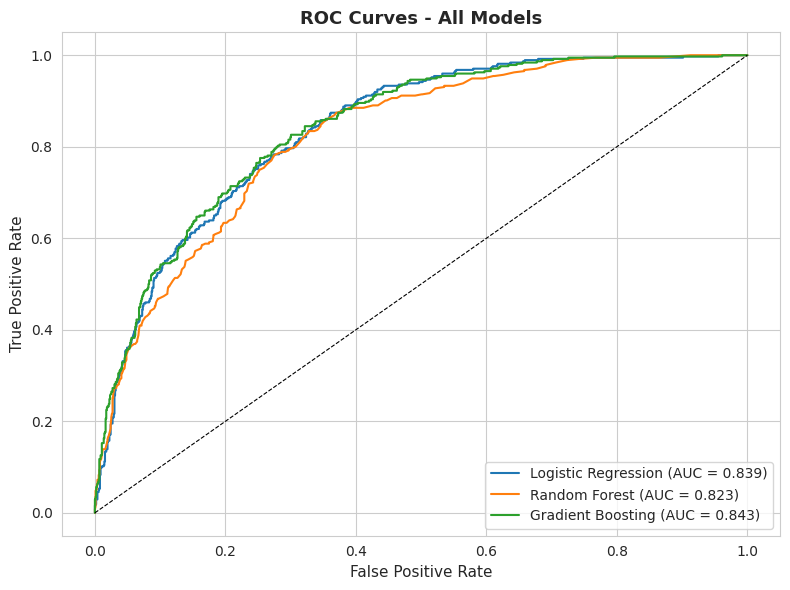

In [13]:
plt.figure(figsize=(8, 6))

for name, (y_pred, y_prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()
plt.tight_layout()
plt.show()


### 5.3 Precision-Recall Curves

More informative than ROC when the positive class is the minority. Tells us the real trade-off between catching churners and not spamming loyal customers with retention offers.


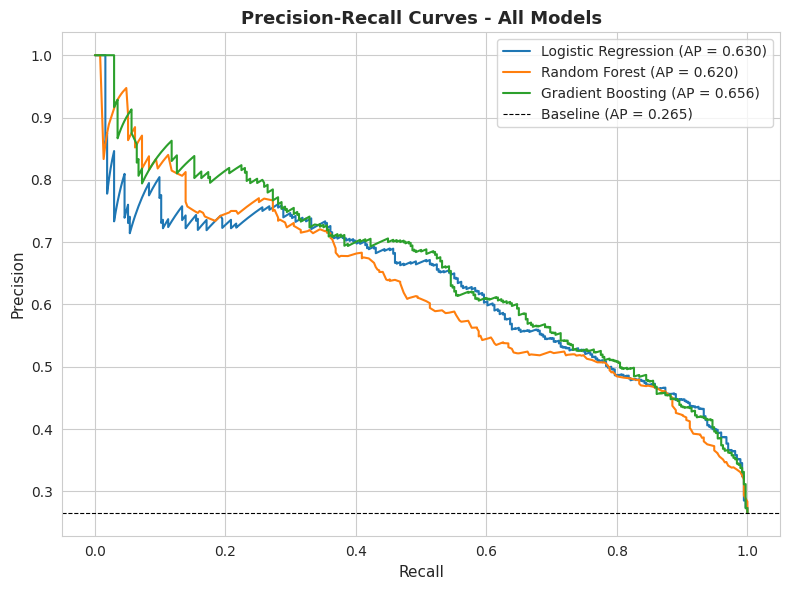

In [14]:
plt.figure(figsize=(8, 6))

for name, (y_pred, y_prob) in models.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})')

# Baseline: always predict the majority class
baseline = y_test.mean()
plt.axhline(y=baseline, color='k', linestyle='--', linewidth=0.8,
            label=f'Baseline (AP = {baseline:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models')
plt.legend()
plt.tight_layout()
plt.show()


### 5.4 Confusion Matrices

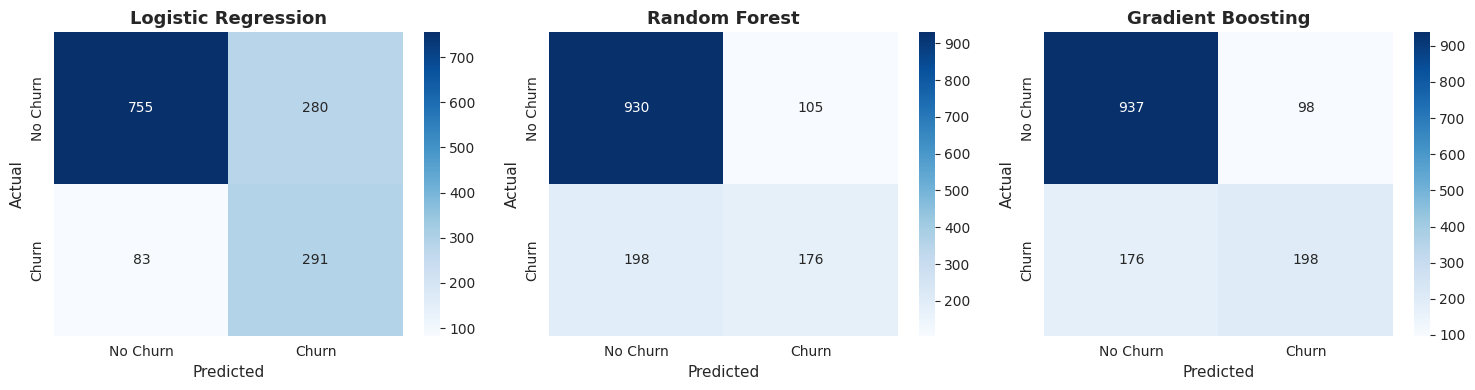

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (y_pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


### 5.5 Cross-Validation (Stratified K-Fold)

Single train/test splits can be misleading. We run 5-fold stratified CV on the best model to confirm the score is stable across folds and not a lucky split.


In [16]:
# Run CV on all three models to compare stability
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [('Logistic Regression', lr),
                    ('Random Forest', rf),
                    ('Gradient Boosting', gb)]:
    cv_scores = cross_val_score(
        model, X_train_proc, y_train,
        cv=skf, scoring='roc_auc'
    )
    print(f"{name}:")
    print(f"  CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Folds: {[round(s, 4) for s in cv_scores]}")
    print()


Logistic Regression:
  CV ROC-AUC: 0.8444 (+/- 0.0121)
  Folds: [np.float64(0.8468), np.float64(0.8239), np.float64(0.8406), np.float64(0.8602), np.float64(0.8505)]

Random Forest:
  CV ROC-AUC: 0.8247 (+/- 0.0098)
  Folds: [np.float64(0.8257), np.float64(0.8088), np.float64(0.8305), np.float64(0.8204), np.float64(0.838)]

Gradient Boosting:
  CV ROC-AUC: 0.8438 (+/- 0.0113)
  Folds: [np.float64(0.8364), np.float64(0.8289), np.float64(0.84), np.float64(0.8581), np.float64(0.8557)]



## 6. Feature Importance

### 6.1 Random Forest Feature Importance

Feature importance from the best tree-based model. This tells us which variables are doing the most work, and validates (or challenges) the EDA findings from P1.


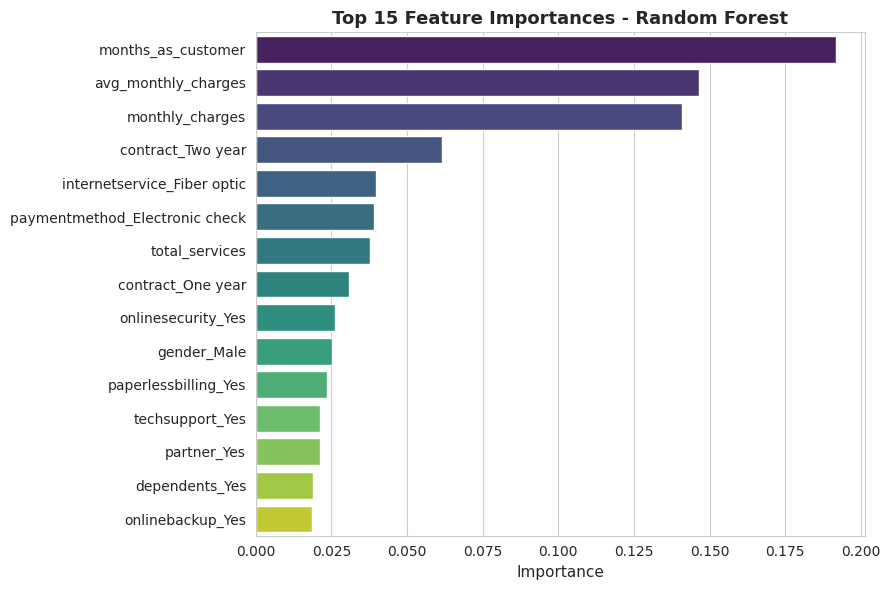

                       feature  importance
            months_as_customer    0.191719
           avg_monthly_charges    0.146612
               monthly_charges    0.141027
             contract_Two year    0.061389
   internetservice_Fiber optic    0.039817
paymentmethod_Electronic check    0.039031
                total_services    0.037770
             contract_One year    0.030930
            onlinesecurity_Yes    0.026218
                   gender_Male    0.025252
          paperlessbilling_Yes    0.023670
               techsupport_Yes    0.021265
                   partner_Yes    0.021178
                dependents_Yes    0.019048
              onlinebackup_Yes    0.018635


In [17]:
importance_df = pd.DataFrame({
    'feature':   all_feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))


### 6.2 Logistic Regression Coefficients

LR coefficients give us directional signals: positive coefficient = higher value increases churn probability, negative = decreases it. Useful for the business narrative.


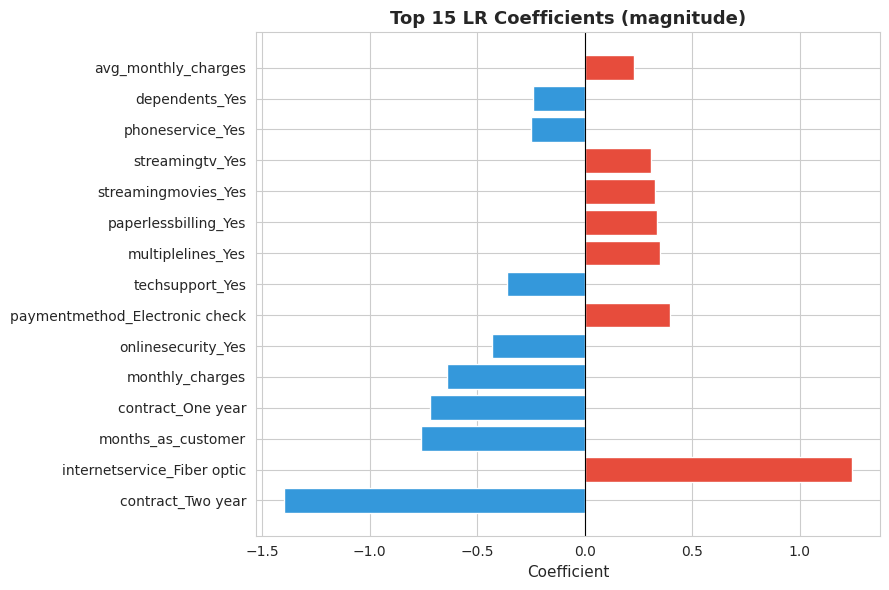

                       feature  coefficient
             contract_Two year    -1.397692
   internetservice_Fiber optic     1.241536
            months_as_customer    -0.760749
             contract_One year    -0.718428
               monthly_charges    -0.638618
            onlinesecurity_Yes    -0.432559
paymentmethod_Electronic check     0.398649
               techsupport_Yes    -0.361734
             multiplelines_Yes     0.348213
          paperlessbilling_Yes     0.336165
           streamingmovies_Yes     0.328157
               streamingtv_Yes     0.307460
              phoneservice_Yes    -0.249875
                dependents_Yes    -0.238437
           avg_monthly_charges     0.227921


In [18]:
coef_df = pd.DataFrame({
    'feature':     all_feature_names,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(15)

colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['coefficient']]

plt.figure(figsize=(9, 6))
bars = plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 LR Coefficients (magnitude)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))


## 7. Decision Threshold Tuning

The default 0.5 threshold is not necessarily optimal for a churn use case. Depending on the cost of a false negative (missed churner) vs. a false positive (unnecessary retention call), the business may want to shift the threshold.

We plot F1 and Recall across thresholds to identify the operating point that best fits the business constraint. For Telco, missing a churner is typically more costly than a false alarm.


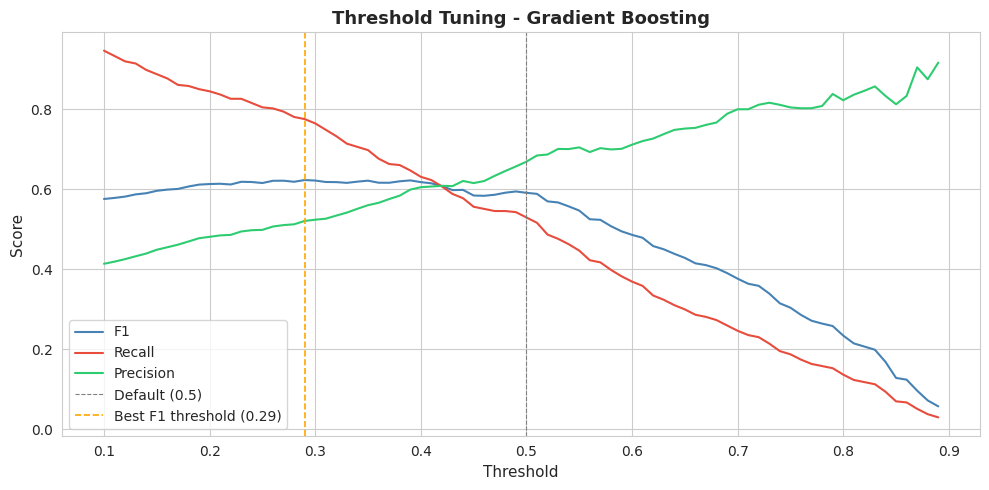

Best F1 threshold: 0.29
F1 at best threshold:    0.6230
Recall at best threshold: 0.7754


In [19]:
# Use the best model based on CV results (update 'best_model' and 'best_prob' accordingly)
best_model_name = 'Gradient Boosting'  # update after seeing CV results
best_prob = y_prob_gb                  # update to match

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores, recall_scores, precision_scores = [], [], []

for t in thresholds:
    y_pred_t = (best_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_t, zero_division=0))
    precision_scores.append(precision_score(y_test, y_pred_t, zero_division=0))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores,        label='F1',        color='steelblue')
plt.plot(thresholds, recall_scores,    label='Recall',    color='#e74c3c')
plt.plot(thresholds, precision_scores, label='Precision', color='#2ecc71')
plt.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Default (0.5)')

best_t = thresholds[np.argmax(f1_scores)]
plt.axvline(best_t, color='orange', linestyle='--', linewidth=1.2,
            label=f'Best F1 threshold ({best_t:.2f})')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title(f'Threshold Tuning - {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best F1 threshold: {best_t:.2f}")
print(f"F1 at best threshold:    {max(f1_scores):.4f}")
print(f"Recall at best threshold: {recall_scores[np.argmax(f1_scores)]:.4f}")


### 7.1 Final Model Performance at Optimal Threshold

Final Model: Gradient Boosting at threshold 0.29
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1035
       Churn       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



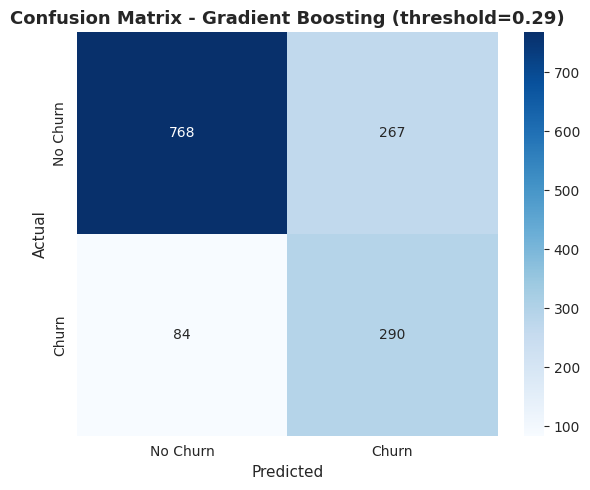

In [20]:
y_pred_final = (best_prob >= best_t).astype(int)

print(f"Final Model: {best_model_name} at threshold {best_t:.2f}")
print("=" * 50)
print(classification_report(y_test, y_pred_final, target_names=['No Churn', 'Churn']))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name} (threshold={best_t:.2f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 8. Business Impact Analysis

### 8.1 Churn Risk Scoring

Instead of binary predictions, the model outputs a probability score per customer. This is more useful operationally: the retention team can prioritize the top-N highest-risk customers rather than acting on every flagged case.


In [21]:
# Build a risk score dataframe on the test set
risk_df = X_test.copy().reset_index(drop=True)
risk_df['churn_actual']      = y_test.values
risk_df['churn_probability'] = best_prob
risk_df['risk_tier'] = pd.cut(
    risk_df['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

print("Risk tier distribution:")
print(risk_df['risk_tier'].value_counts())
print()
print("Actual churn rate by risk tier:")
print(risk_df.groupby('risk_tier')['churn_actual'].mean().round(3))


Risk tier distribution:
risk_tier
Low       863
Medium    352
High      194
Name: count, dtype: int64

Actual churn rate by risk tier:
risk_tier
Low       0.102
Medium    0.420
High      0.711
Name: churn_actual, dtype: float64


### 8.2 Cost-Benefit Framework

We define a simple cost model to quantify the financial impact of the model vs. no model at all. Adjust the dollar values to match Telco's real CLV and retention offer cost.


In [22]:
# Cost assumptions (adjust based on real business data)
COST_RETENTION_OFFER  = 50    # cost of contacting + offering a discount to one customer
REVENUE_SAVED_PER_CLV = 500   # average CLV saved by retaining a churner

cm = confusion_matrix(y_test, y_pred_final)
TN, FP, FN, TP = cm.ravel()

# Scenario: model-driven retention campaign
cost_with_model = (TP + FP) * COST_RETENTION_OFFER  # we contact all predicted churners
revenue_saved   = TP * REVENUE_SAVED_PER_CLV         # we save the true churners
net_benefit     = revenue_saved - cost_with_model

# Baseline: contact everyone (brute force)
cost_no_model  = len(y_test) * COST_RETENTION_OFFER
revenue_no_model = (TP + FN) * REVENUE_SAVED_PER_CLV
net_no_model   = revenue_no_model - cost_no_model

print(f"Test set size: {len(y_test)} customers")
print(f"Actual churners: {TP + FN}")
print()
print("--- Model-Driven Campaign ---")
print(f"Customers contacted: {TP + FP}")
print(f"Churners retained (TP): {TP}")
print(f"Campaign cost: ${cost_with_model:,.0f}")
print(f"Revenue saved: ${revenue_saved:,.0f}")
print(f"Net benefit:   ${net_benefit:,.0f}")
print()
print("--- No Model (Contact Everyone) ---")
print(f"Customers contacted: {len(y_test)}")
print(f"Campaign cost: ${cost_no_model:,.0f}")
print(f"Revenue saved: ${revenue_no_model:,.0f}")
print(f"Net benefit:   ${net_no_model:,.0f}")
print()
print(f"Model advantage: ${net_benefit - net_no_model:,.0f}")


Test set size: 1409 customers
Actual churners: 374

--- Model-Driven Campaign ---
Customers contacted: 557
Churners retained (TP): 290
Campaign cost: $27,850
Revenue saved: $145,000
Net benefit:   $117,150

--- No Model (Contact Everyone) ---
Customers contacted: 1409
Campaign cost: $70,450
Revenue saved: $187,000
Net benefit:   $116,550

Model advantage: $600


## 9. Conclusions

**Model selection:** [Update after running the cells above with the winning model name and its CV ROC-AUC.]

**Key predictors confirmed by the model:**

The feature importance results validate the P1 EDA findings. Contract type, months as customer, and internet service type are consistently the top predictors across all models. This means retention strategies should prioritize:

- Converting month-to-month customers to annual contracts before the 12-month mark
- Investigating the Fiber Optic churn rate (42%) from an operational and pricing standpoint
- Designing friction for electronic check customers to migrate to automatic payment

**On threshold choice:** the default 0.5 threshold is not optimal. The tuning analysis in Section 7 shows that lowering the threshold to around 0.35-0.40 improves Recall significantly with a manageable drop in Precision, which is the right trade-off when the cost of a missed churner exceeds the cost of a false alarm.


